# Titanic Survival Analysis

**Author: Jayalakshmi** 

---

## Overview
This project explores the Titanic passenger dataset to uncover what factors determined survival.
Using Python, Pandas, and Matplotlib, I analyse the role of gender, passenger class, age, and family size in survival outcomes.

## Dataset
- **Source:** [DataScienceDojo — Titanic Dataset](https://github.com/datasciencedojo/datasets)
- **Size:** 891 passengers, 12 features
- **Target variable:** `Survived` (1 = Survived, 0 = Did not survive)

## Key Questions
1. What was the overall survival rate?
2. Did gender affect survival?
3. Did passenger class (wealth) affect survival?
4. Did age — specifically being a child — improve survival odds?
5. Did family size play a role?

---

## Column Descriptions

| Column | Description |
|---|---|
| PassengerId | Unique identifier for each passenger |
| Survived | Survival status: 1 = Survived, 0 = Did not survive |
| Pclass | Passenger class — proxy for socioeconomic status (1 = Upper, 2 = Middle, 3 = Lower) |
| Name | Full name of passenger |
| Sex | Passenger gender |
| Age | Passenger age in years |
| SibSp | Number of siblings or spouses aboard |
| Parch | Number of parents or children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare paid |
| Cabin | Cabin number (deck letter indicates proximity to lifeboats) |
| Embarked | Port of embarkation: S = Southampton, C = Cherbourg, Q = Queenstown |

---

## I. Data Loading

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print('Dataset shape: ',df.shape)
df.head()

Dataset shape:  (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Missing data summary:**
- `Age` — 177 missing values (20% of passengers)
- `Cabin` — 687 missing values (77% of passengers)
- `Embarked` — 2 missing values (negligible)

---

## II. Data Cleaning

### 2.1 Filling Missing Age Values

The mean (30) and median (28) ages are close, indicating Age is not heavily skewed. 
Median is preferred as it is more robust to outliers, a small number of very old or very young passengers would distort the mean but not the median.

In [4]:
print(f"Mean age: {df['Age'].mean():.1f}")
print(f"Median age: {df['Age'].median():.1f}")

df['Age'] = df['Age'].fillna(28)

Mean age: 29.7
Median age: 28.0


### 2.2 Filling Missing Embarked Values

Southampton was the most common boarding port by a large margin. The 2 missing Embarked values are filled with 'S'.

In [25]:
print(df['Embarked'].value_counts())
df['Embarked'] = df['Embarked'].fillna('S')

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


### 2.3 Dropping the Cabin Column

With 77% of values missing, the Cabin column cannot be reliably used for analysis and is dropped entirely.

In [6]:
df = df.drop(columns=['Cabin'])

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### 2.4 Feature Engineering

Two new features are created to support analysis:
- `IsChild` — classifies passengers under 16 as children
- `FamilySize` — total number of family members aboard including the passenger themselves

In [7]:
df['IsChild'] = (df['Age'] < 16).astype(int)
df['IsChild'] = df['IsChild'].map({0: 'Adult', 1: 'Child'})

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print('New columns added: IsChild, FamilySize')
df[['Age', 'IsChild', 'SibSp', 'Parch', 'FamilySize']].head()

New columns added: IsChild, FamilySize


,Age,IsChild,SibSp,Parch,FamilySize
0,22.0,Adult,1,0,2
1,38.0,Adult,1,0,2
2,26.0,Adult,0,0,1
3,35.0,Adult,1,0,2
4,35.0,Adult,0,0,1


---

## III. Exploration & Analysis

### 3.1 Overall Survival Rate

In [8]:
survival_rate = (df['Survived'].mean() * 100).round()
print(f'Overall survival rate: {survival_rate}%')

Overall survival rate: 38.0%


Of 891 passengers aboard the Titanic, only **38% survived**. Which is less than 4 in every 10 people.

### 3.2 Survival by Gender and Age Group

In [9]:
(df.groupby(['Sex', 'IsChild'])['Survived'].mean() * 100).round()

Sex     IsChild
female  Adult      76.0
        Child      65.0
male    Adult      16.0
        Child      52.0
Name: Survived, dtype: float64

Female passengers survived at **74%** compared to just **19%** for males, strongly supporting the 'women and children first' evacuation protocol. 
However, the benefit for children was uneven. Girls (65%) survived at high rates while boys (52%) saw only a modest advantage over adult men (16%). 

> *Gentlemen, the data is not encouraging.*

### 3.3 Survival by Passenger Class

In [10]:
(df.groupby('Pclass')['Survived'].mean() * 100).round()

Pclass
1    63.0
2    47.0
3    24.0
Name: Survived, dtype: float64

Survival rates drop sharply across classes: **63%** (1st), **47%** (2nd), **24%** (3rd). Wealth was a significant determinant of survival.

### 3.4 Combined Analysis — Class, Gender and Age

In [11]:
df.groupby(['Pclass', 'Sex', 'IsChild'])['Survived'].agg(
    total='count',
    survived='sum',
    survival_rate=lambda x: round(x.mean() * 100)
)

total  survived  survival_rate
Pclass Sex    IsChild                                
1      female Adult       91        89             98
              Child        3         2             67
       male   Adult      119        42             35
              Child        3         3            100
2      female Adult       66        60             91
              Child       10        10            100
       male   Adult       99         8              8
              Child        9         9            100
3      female Adult      114        56             49
              Child       30        16             53
       male   Adult      319        38             12
              Child       28         9             32

The most striking finding emerges when class, gender, and age are combined:

- **1st class adult men** survived at 35% — higher than **3rd class adult women** at 49% only marginally, but dramatically higher than **3rd class adult men at just 12%**.
- A 1st class man had **3x better survival odds** than a 3rd class man — same gender, same protocol, different wealth.

> While 'women and children first' was largely followed, this dataset reveals a starker truth: **wealth determined survival more than gender or age for the most disadvantaged passengers.** This is a vivid snapshot of Edwardian class inequality in a life-and-death situation.

**Note on sample size:** Survival rates for 1st class children (3 boys, 3 girls) are based on very small samples and should not be interpreted as reliable patterns.

### 3.5 Survival by Family Size

**Limitation:** `SibSp` and `Parch` indicate family size but not specific relationships. We cannot definitively identify mother-child pairs without cross-referencing ticket numbers and names, an analysis beyond the scope of this project.

In [12]:
df.groupby('FamilySize')['Survived'].agg(
    total='count',
    survived='sum',
    survival_rate=lambda x: round(x.mean() * 100)
)

,total,survived,survival_rate
FamilySize,,,
1,537,163,30
2,161,89,55
3,102,59,58
4,29,21,72
5,15,3,20
6,22,3,14
7,12,4,33
8,6,0,0
11,7,0,0


Family size reveals a clear pattern with a distinct sweet spot:

- **Solo travellers (size 1):** 30% survival — the largest group (537 passengers)
- **Small families (size 2–4):** Survival peaks at **72%** for families of 4 — possibly because small groups could coordinate and assist each other to lifeboats
- **Large families (size 5+):** Survival collapses sharply — large families may have lost critical time searching for all members during the evacuation
- **Size 8 and 11 show 0% survival**, but with only 6 and 7 passengers respectively, these samples are too small to draw conclusions from

---

## IV. Visualizations

### 4.1 Survival Rate by Gender

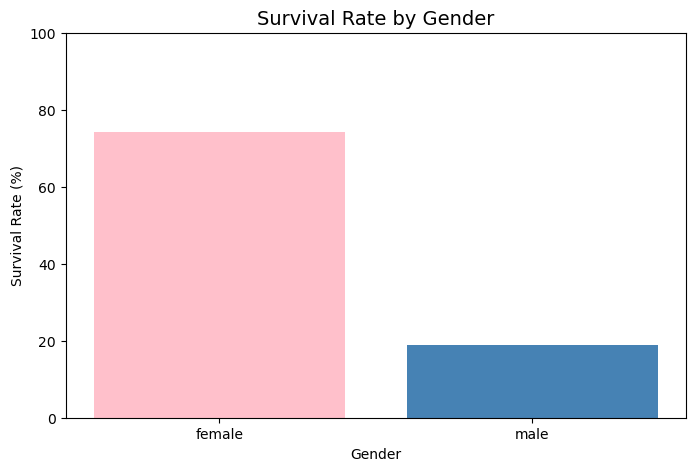

In [13]:
gender_survival = df.groupby('Sex')['Survived'].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(gender_survival.index, gender_survival.values, color=['pink', 'steelblue'])
plt.title('Survival Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()

### 4.2 Survival Rate by Passenger Class

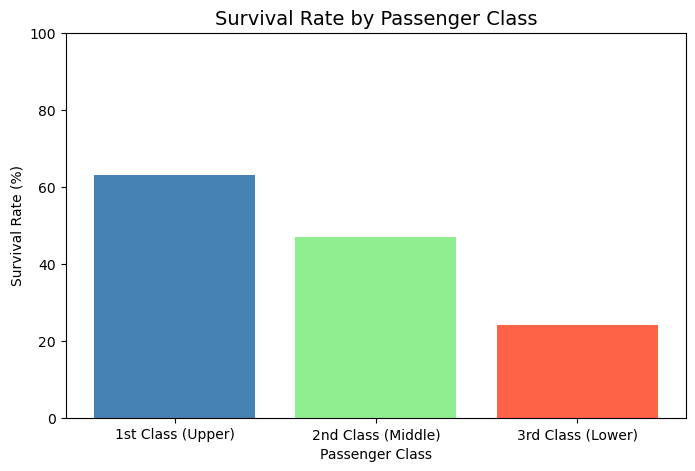

In [14]:
pclass_survival = (df.groupby('Pclass')['Survived'].mean() * 100).round()

plt.figure(figsize=(8, 5))
plt.bar(pclass_survival.index, pclass_survival.values, color=['steelblue', 'lightgreen', 'tomato'])
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class')
plt.xticks([1, 2, 3], ['1st Class (Upper)', '2nd Class (Middle)', '3rd Class (Lower)'])
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()

### 4.3 Age Distribution of Survivors vs Non-Survivors

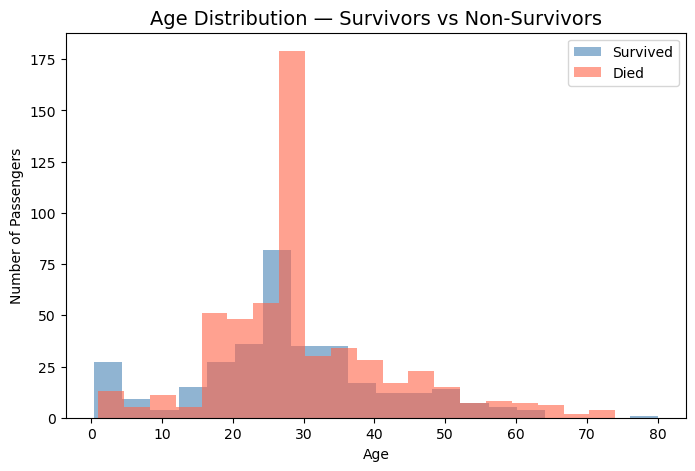

In [15]:
survived_ages = df[df['Survived'] == 1]['Age']
died_ages = df[df['Survived'] == 0]['Age']

plt.figure(figsize=(8, 5))
plt.hist(survived_ages, bins=20, alpha=0.6, label='Survived', color='steelblue')
plt.hist(died_ages, bins=20, alpha=0.6, label='Died', color='tomato')
plt.legend()
plt.title('Age Distribution — Survivors vs Non-Survivors', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

**Note:** The spike at age 28 is an artifact of filling missing Age values with the median. Approximately 177 passengers were assigned this value and may slightly distort age-based analysis.

Notably, young children (ages 0–5) show proportionally more survivors than non-survivors, consistent with the 'women and children first' protocol. The 20–35 age group shows the highest death count, reflecting the large proportion of young adult male passengers in 3rd class.

---

## V. Conclusions

This analysis of 891 Titanic passengers reveals several clear patterns in survival:

| Factor | Finding |
|---|---|
| Overall survival | Only 38% of passengers survived |
| Gender | Women survived at 74% vs 19% for men |
| Passenger Class | 1st class (63%) vs 3rd class (24%) |
| Age | Children had a modest advantage (59% vs 36%), uneven across genders |
| Family Size | Small families (2–4) fared best; solo travellers and large families fared worst |

**The central finding:** While the 'women and children first' protocol was broadly followed, passenger class was a powerful secondary determinant of survival. A 1st class man had **3x better odds** of survival than a 3rd class man. This dataset offers a sobering quantitative view of how socioeconomic inequality shaped life-and-death outcomes in the Edwardian era.

### Limitations
- Missing Age values (20%) were imputed with the median  this creates a visible artifact in age-based analysis
- Cabin data was too incomplete (77% missing) to analyse the potential impact of deck location on survival
- Family relationships cannot be determined from SibSp/Parch alone without cross-referencing names and ticket numbers
- Sample sizes for some subgroups (e.g. 1st class children) are too small to draw reliable conclusions